# Cognisense — 01: Exploratory Data Analysis

Explores the **synthetic** behavioral dataset used to train Cognisense.

> ⚠️ This data is simulated, not collected from human participants. The goal of this
> notebook is to verify that the generated data has the properties real behavioral
> data has — especially **class overlap**. Cleanly separated classes would make the
> downstream accuracy meaningless.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="rocket")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [2]:
from dataset_generator import generate_cognitive_load_dataset
from preprocessing import FEATURE_COLUMNS, CLASS_NAMES, GROUP_COLUMN

df = pd.read_csv(os.path.join("..", "data", "raw", "cognitive_load_behavior_dataset.csv"))
df["load_name"] = df["cognitive_load"].map(dict(enumerate(CLASS_NAMES)))

print(f"Shape            : {df.shape}")
print(f"Simulated people : {df[GROUP_COLUMN].nunique()}")
print(f"Missing values   : {int(df.isna().sum().sum())}")
df.head()

Shape            : (3000, 15)
Simulated people : 60
Missing values   : 0


,typing_speed_wpm,avg_keystroke_interval_ms,backspace_ratio,pause_frequency_per_min,mouse_velocity_px_s,mouse_distance_px,click_frequency_per_min,idle_time_seconds,error_rate,response_time_seconds,retry_count,context_switches_per_min,cognitive_load,subject_id,load_name
0,45.6497,156.0779,0.0430,8,193.0830,1925.9644,23.5501,0.8904,0.0640,6.1889,1,8,1,28,Medium
1,62.3595,191.5831,0.0652,6,322.0643,1858.6351,18.4194,3.5618,0.0000,3.4870,4,5,1,48,Medium
2,26.4681,242.1343,0.1143,10,96.5927,1760.6369,19.7652,14.5751,0.0942,9.3770,2,3,1,21,Medium
3,72.5139,80.0000,0.0512,0,253.1726,939.4892,7.6856,11.0712,0.0000,1.9880,2,2,0,36,Low
4,34.5929,410.8776,0.1527,8,335.8637,2694.5431,15.7595,6.0221,0.0827,7.2365,0,5,2,1,High


## 1. Class balance and target distribution

load_name
Medium    1000
Low       1000
High      1000


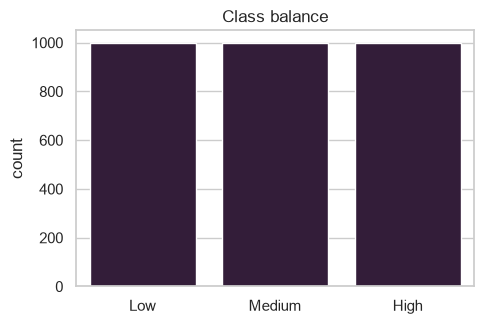

In [3]:
print(df["load_name"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(5, 3.4))
sns.countplot(data=df, x="load_name", order=CLASS_NAMES, ax=ax)
ax.set_title("Class balance")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 2. Descriptive statistics by class

The **standard deviations matter more than the means here**. If within-class spread is
small relative to the gaps between class means, the classes are trivially separable and
any model will score ~99%.

In [4]:
summary = df.groupby("load_name")[FEATURE_COLUMNS].agg(["mean", "std"]).round(2)
summary.reindex(CLASS_NAMES)[
    ["typing_speed_wpm", "error_rate", "response_time_seconds", "pause_frequency_per_min"]
]

typing_speed_wpm        error_rate       response_time_seconds       pause_frequency_per_min      
                      mean    std       mean   std                  mean   std                    mean   std
load_name                                                                                                   
Low                  57.39  15.94       0.04  0.05                  4.39  3.19                    2.43  2.30
Medium               46.42  14.68       0.10  0.05                  7.81  3.23                    5.47  2.56
High                 36.51  15.68       0.15  0.06                 11.57  3.75                    8.82  3.19

## 3. Distribution overlap — the key diagnostic

Each class distribution should visibly **overlap** its neighbours. This is what makes the
classification problem non-trivial and the reported metrics meaningful.

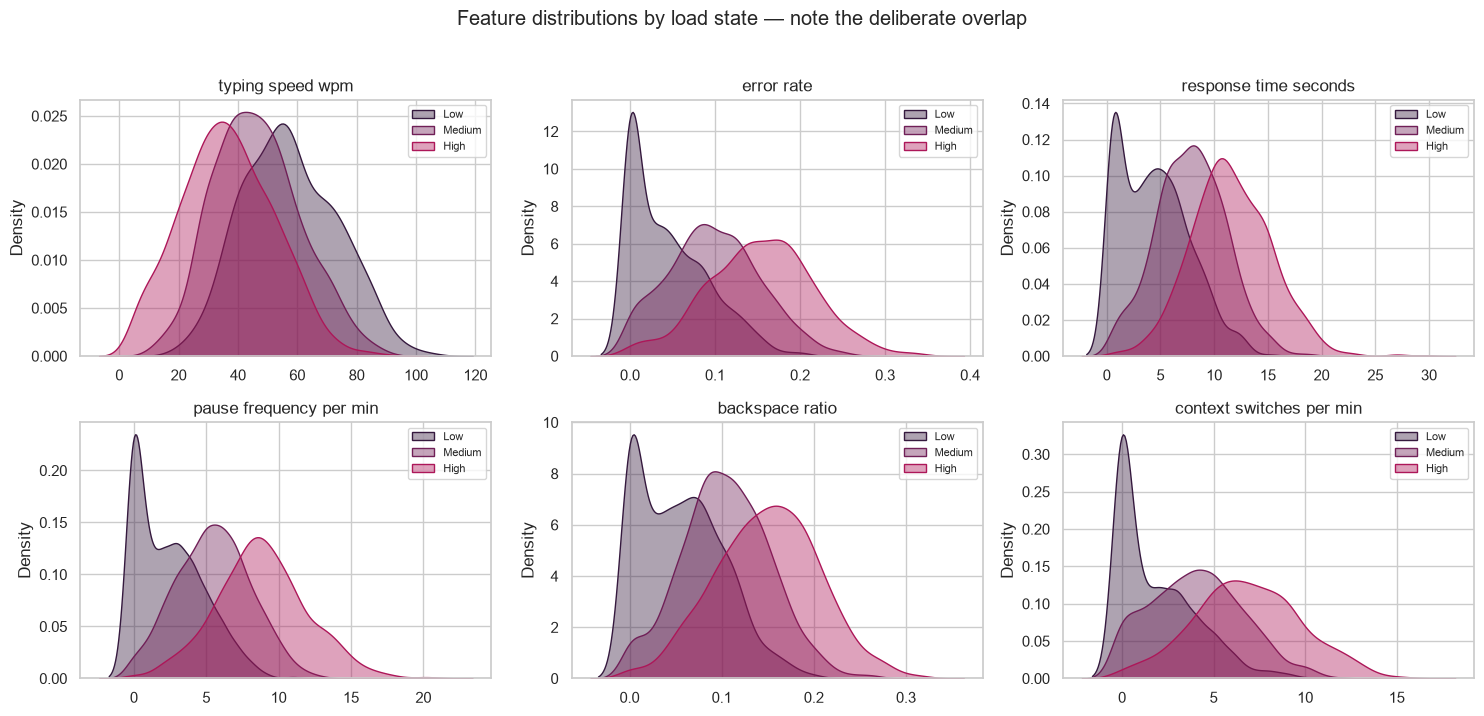

In [5]:
key_features = ["typing_speed_wpm", "error_rate", "response_time_seconds",
                "pause_frequency_per_min", "backspace_ratio", "context_switches_per_min"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feature in zip(axes.ravel(), key_features):
    for state in CLASS_NAMES:
        sns.kdeplot(data=df[df["load_name"] == state], x=feature,
                    fill=True, alpha=0.4, label=state, ax=ax)
    ax.set_title(feature.replace("_", " "))
    ax.set_xlabel("")
    ax.legend(fontsize=8)

fig.suptitle("Feature distributions by load state — note the deliberate overlap", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Quantify separability: gap between Low and High means, in pooled std units.
print("Separability (Low-High mean gap / pooled std) — lower means harder:\n")
rows = []
for feature in FEATURE_COLUMNS:
    grouped = df.groupby("cognitive_load")[feature]
    means, stds = grouped.mean(), grouped.std()
    gap = abs(means[2] - means[0])
    pooled = stds.mean()
    rows.append({"feature": feature, "separability": round(gap / pooled, 2)})

sep = pd.DataFrame(rows).sort_values("separability", ascending=False)
print(sep.to_string(index=False))
print("\nAll values well below ~3.0 => no single feature trivially solves the task.")

Separability (Low-High mean gap / pooled std) — lower means harder:

                  feature  separability
  pause_frequency_per_min          2.38
    response_time_seconds          2.12
               error_rate          2.02
 context_switches_per_min          1.97
          backspace_ratio          1.88
        idle_time_seconds          1.71
              retry_count          1.65
avg_keystroke_interval_ms          1.65
  click_frequency_per_min          1.60
      mouse_velocity_px_s          1.59
        mouse_distance_px          1.45
         typing_speed_wpm          1.35

All values well below ~3.0 => no single feature trivially solves the task.


## 4. Feature correlations

Features are driven by a shared latent load factor, so they **co-vary**. This is realistic:
in genuine interaction data, slowing down, pausing, and erring happen together. A generator
producing conditionally independent features would show a near-empty correlation matrix.

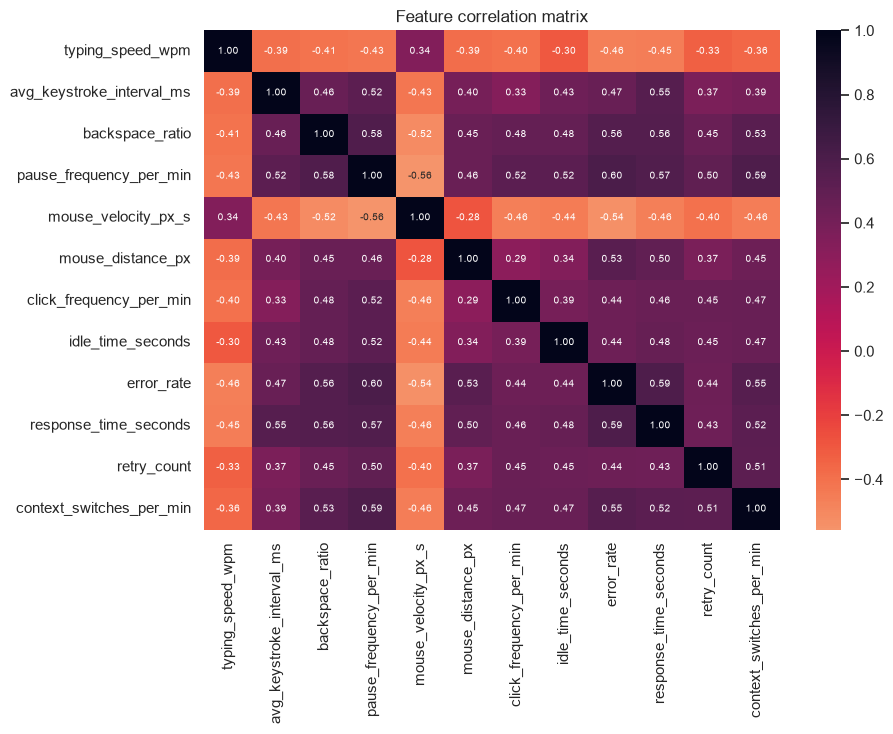

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 7.5))
corr = df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket_r", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

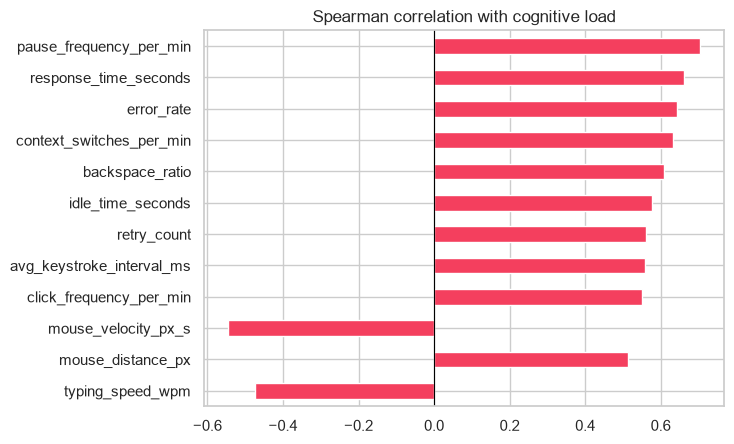

,spearman_vs_load
pause_frequency_per_min,0.705
response_time_seconds,0.662
error_rate,0.642
context_switches_per_min,0.632
backspace_ratio,0.609
idle_time_seconds,0.577
retry_count,0.561
avg_keystroke_interval_ms,0.559
click_frequency_per_min,0.550
mouse_velocity_px_s,-0.546


In [8]:
# Correlation of each feature with the load label (Spearman = monotonic association).
label_corr = (df[FEATURE_COLUMNS]
              .apply(lambda s: s.corr(df["cognitive_load"], method="spearman"))
              .sort_values(key=abs, ascending=False)
              .round(3))

fig, ax = plt.subplots(figsize=(7.5, 4.6))
label_corr.plot(kind="barh", ax=ax, color="#f43f5e")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Spearman correlation with cognitive load")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

label_corr.to_frame("spearman_vs_load")

## 5. Individual differences

Each simulated subject has their own behavioral baseline. Because per-subject means vary
widely, an **absolute** typing speed is not diagnostic on its own — which is exactly why
the model needs multiple correlated signals, and why personalized baselines (PRD §23) help.

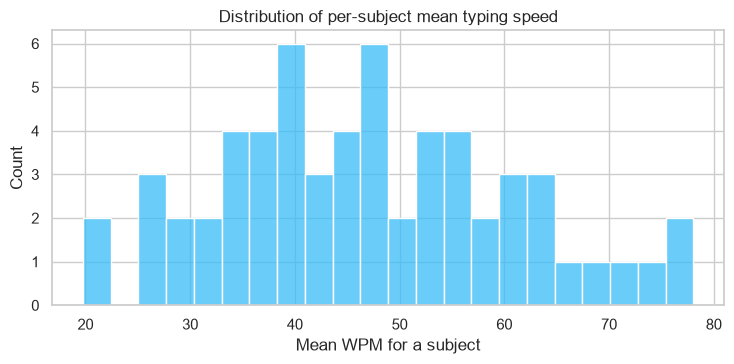

Slowest subject baseline: 19.8 WPM
Fastest subject baseline: 78.1 WPM

A fast typist under HIGH load can still out-type a slow typist at LOW load:
  Fastest subject @ HIGH load: 60.3 WPM
  Slowest subject @ LOW  load: 31.5 WPM


In [9]:
per_subject = df.groupby(GROUP_COLUMN)["typing_speed_wpm"].mean()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
sns.histplot(per_subject, bins=22, ax=ax, color="#38bdf8")
ax.set_title("Distribution of per-subject mean typing speed")
ax.set_xlabel("Mean WPM for a subject")
plt.tight_layout()
plt.show()

print(f"Slowest subject baseline: {per_subject.min():.1f} WPM")
print(f"Fastest subject baseline: {per_subject.max():.1f} WPM")
print("\nA fast typist under HIGH load can still out-type a slow typist at LOW load:")
fast_high = df[(df[GROUP_COLUMN] == per_subject.idxmax()) & (df["cognitive_load"] == 2)]
slow_low = df[(df[GROUP_COLUMN] == per_subject.idxmin()) & (df["cognitive_load"] == 0)]
if len(fast_high) and len(slow_low):
    print(f"  Fastest subject @ HIGH load: {fast_high['typing_speed_wpm'].mean():.1f} WPM")
    print(f"  Slowest subject @ LOW  load: {slow_low['typing_speed_wpm'].mean():.1f} WPM")

## Takeaways

1. Classes are **balanced** and contain **no missing values**.
2. Every feature distribution **overlaps** across states; no single feature separates them.
3. Features are **correlated**, driven by a shared latent load factor.
4. **Between-subject variation is large**, so absolute values are weak evidence alone.

These properties are why the models land in a realistic ~75–84% band rather than ~99%.

→ Continue to `02_model_training.ipynb`.